Datasets           : 11
Classifiers        : ['RF', 'LGBM', 'MLP']
Candidate mult.    : 5.0x
Fixed α values     : [0.1, 0.2, 0.3]
Adaptive α range   : [0.1, 0.3]
Target ratio       : 0.5
Classifiers & Evaluation ready.
GMM clustering ready.
Quality score functions ready.
Adaptive α ready.
MMD ready.
CTGAN functions ready.
Two-stage filtering ready.
Q-G-CTGAN pipeline ready.

Dataset : credit_default  |  n_train=21,000  |  minority=22.12%

  ── Q-G-CTGAN_a0.1 ──
  GMM: best_k=9  cluster_sizes=[378, 539, 461, 1040, 335, 181, 478, 609, 624]
  Training 9 CTGAN models...
    Cluster 0: n=378  ✓
    Cluster 1: n=539  ✓
    Cluster 2: n=461  ✓
    Cluster 3: n=1040  ✓
    Cluster 4: n=335  ✓
    Cluster 5: n=181  ✓
    Cluster 6: n=478  ✓
    Cluster 7: n=609  ✓
    Cluster 8: n=624  ✓
  Generating candidates (×5.0)...
  Total candidates generated: 23,225
  Fixed α=0.1 for all clusters
  Filtering by quality score Q(x̃)...
  Filtered: 23,225 → 11,710 samples [36.0s]
  MMD² before=0.010686  af

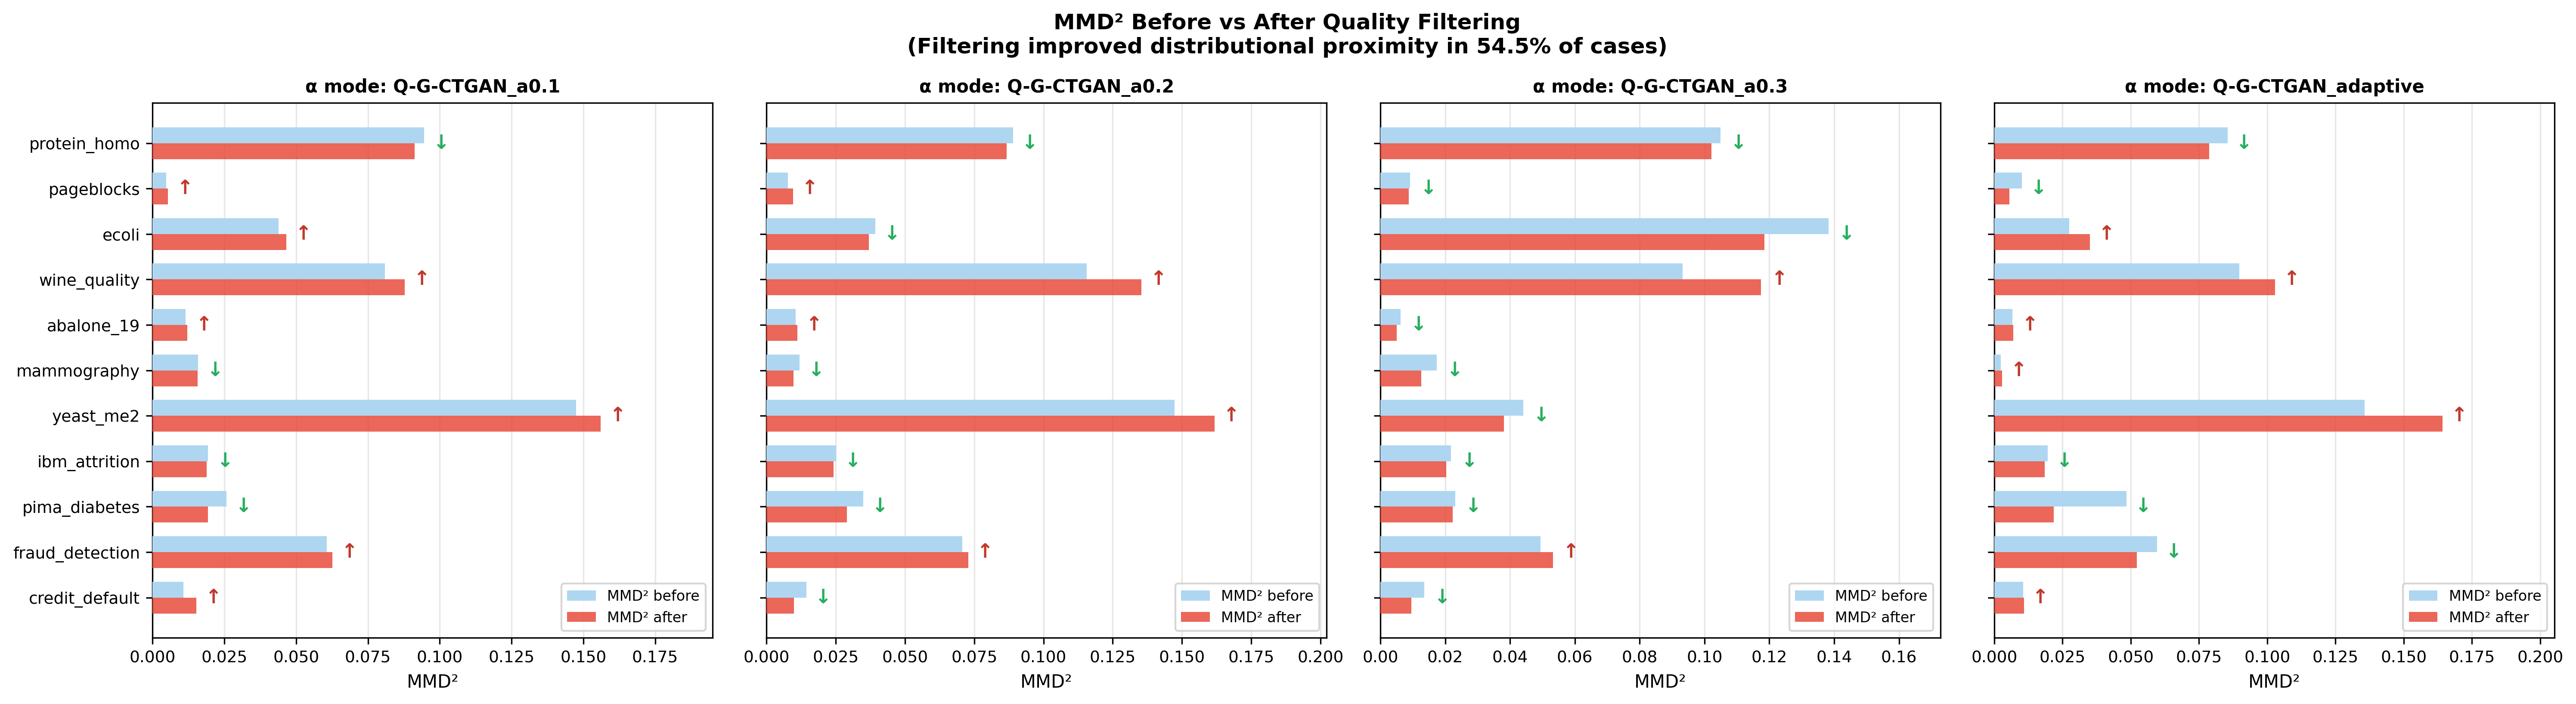


MMD Summary (mean per α mode):
                    mmd_before  mmd_after  mmd_reduction
alpha_mode                                              
Q-G-CTGAN_a0.1          0.0469     0.0482        -0.0014
Q-G-CTGAN_a0.2          0.0515     0.0534        -0.0019
Q-G-CTGAN_a0.3          0.0474     0.0462         0.0012
Q-G-CTGAN_adaptive      0.0451     0.0454        -0.0004
Figure saved → ./results\03_ablation_alpha.png / .pdf


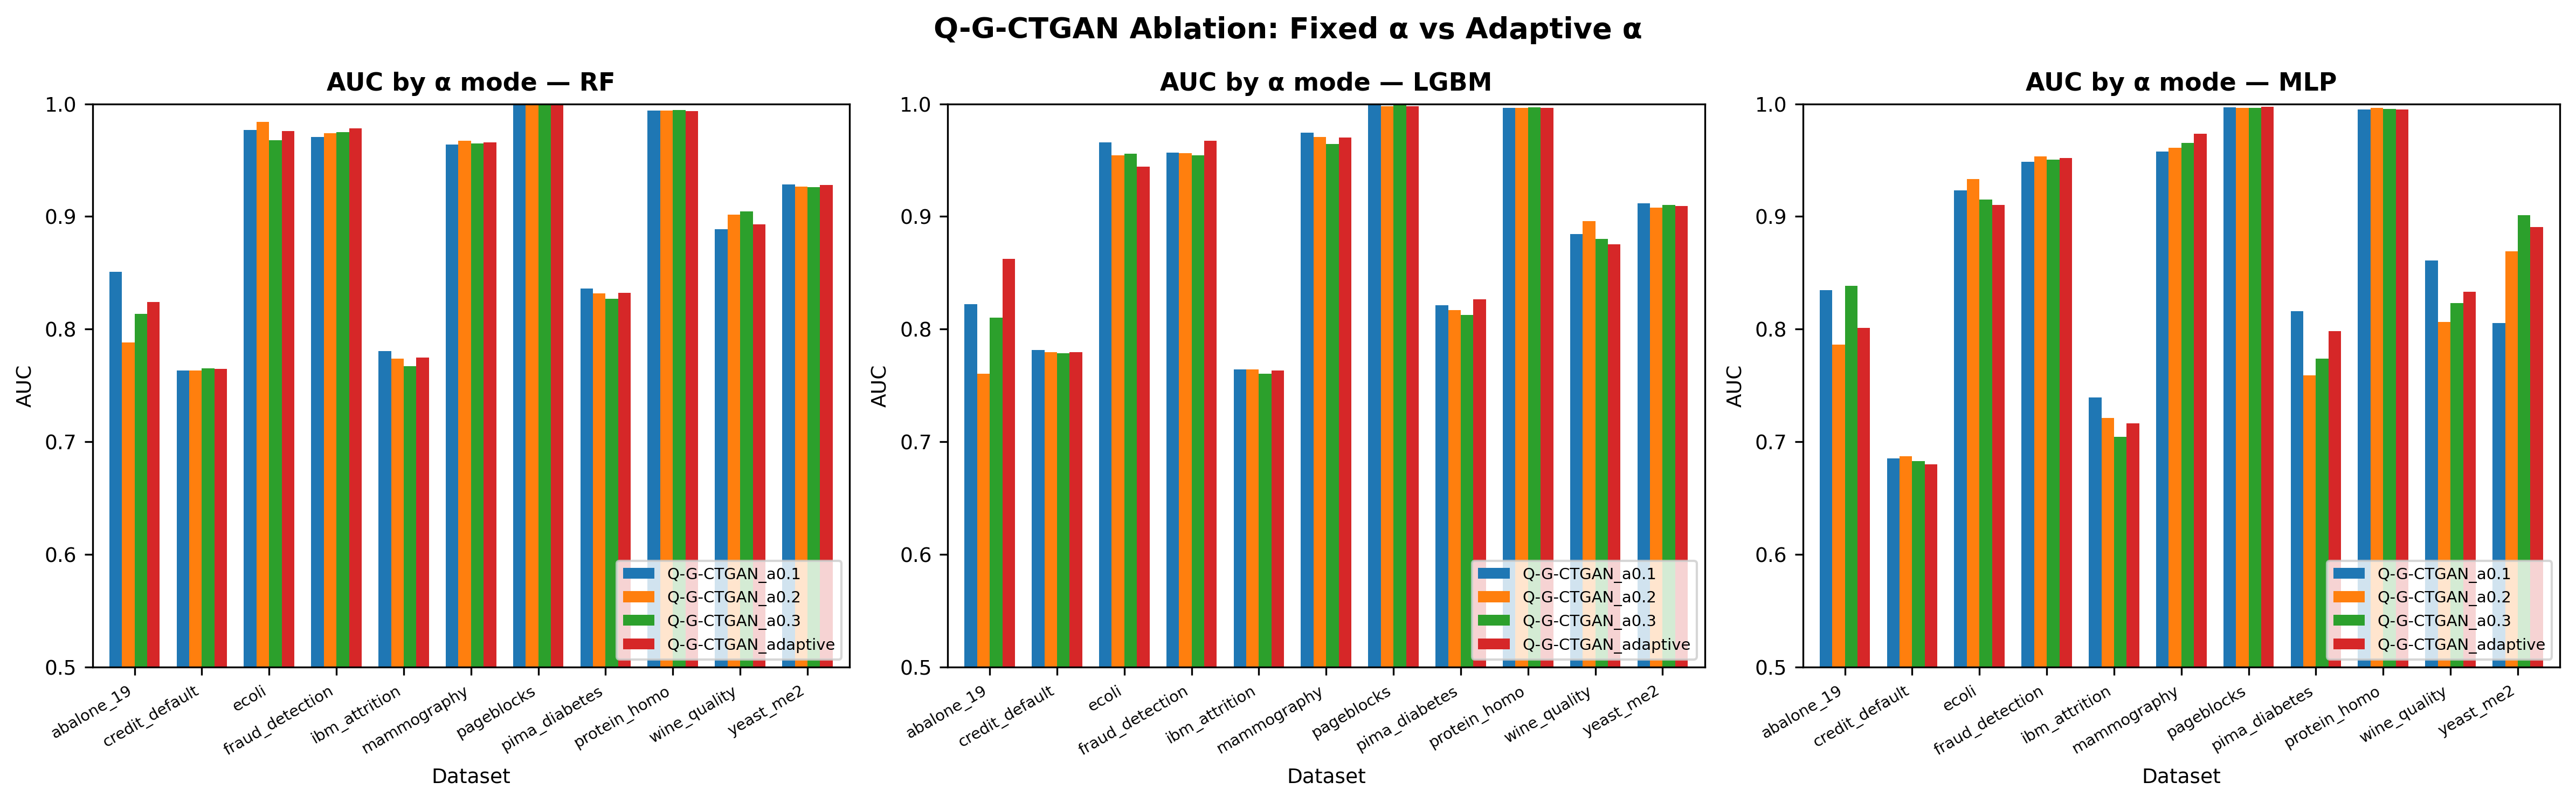


Running quality indicator ablation (RF only)...
    Cluster 0: n=378  ✓
    Cluster 1: n=539  ✓
    Cluster 2: n=461  ✓
    Cluster 3: n=1040  ✓
    Cluster 4: n=335  ✓
    Cluster 5: n=181  ✓
    Cluster 6: n=478  ✓
    Cluster 7: n=609  ✓
    Cluster 8: n=624  ✓
  credit_default | full     | AUC=0.7638
    Cluster 0: n=378  ✓
    Cluster 1: n=539  ✓
    Cluster 2: n=461  ✓
    Cluster 3: n=1040  ✓
    Cluster 4: n=335  ✓
    Cluster 5: n=181  ✓
    Cluster 6: n=478  ✓
    Cluster 7: n=609  ✓
    Cluster 8: n=624  ✓
  credit_default | density  | AUC=0.7645
    Cluster 0: n=378  ✓
    Cluster 1: n=539  ✓
    Cluster 2: n=461  ✓
    Cluster 3: n=1040  ✓
    Cluster 4: n=335  ✓
    Cluster 5: n=181  ✓
    Cluster 6: n=478  ✓
    Cluster 7: n=609  ✓
    Cluster 8: n=624  ✓
  credit_default | sep      | AUC=0.7628
    Cluster 0: n=378  ✓
    Cluster 1: n=539  ✓
    Cluster 2: n=461  ✓
    Cluster 3: n=1040  ✓
    Cluster 4: n=335  ✓
    Cluster 5: n=181  ✓
    Cluster 6: n=478  ✓
    Clus

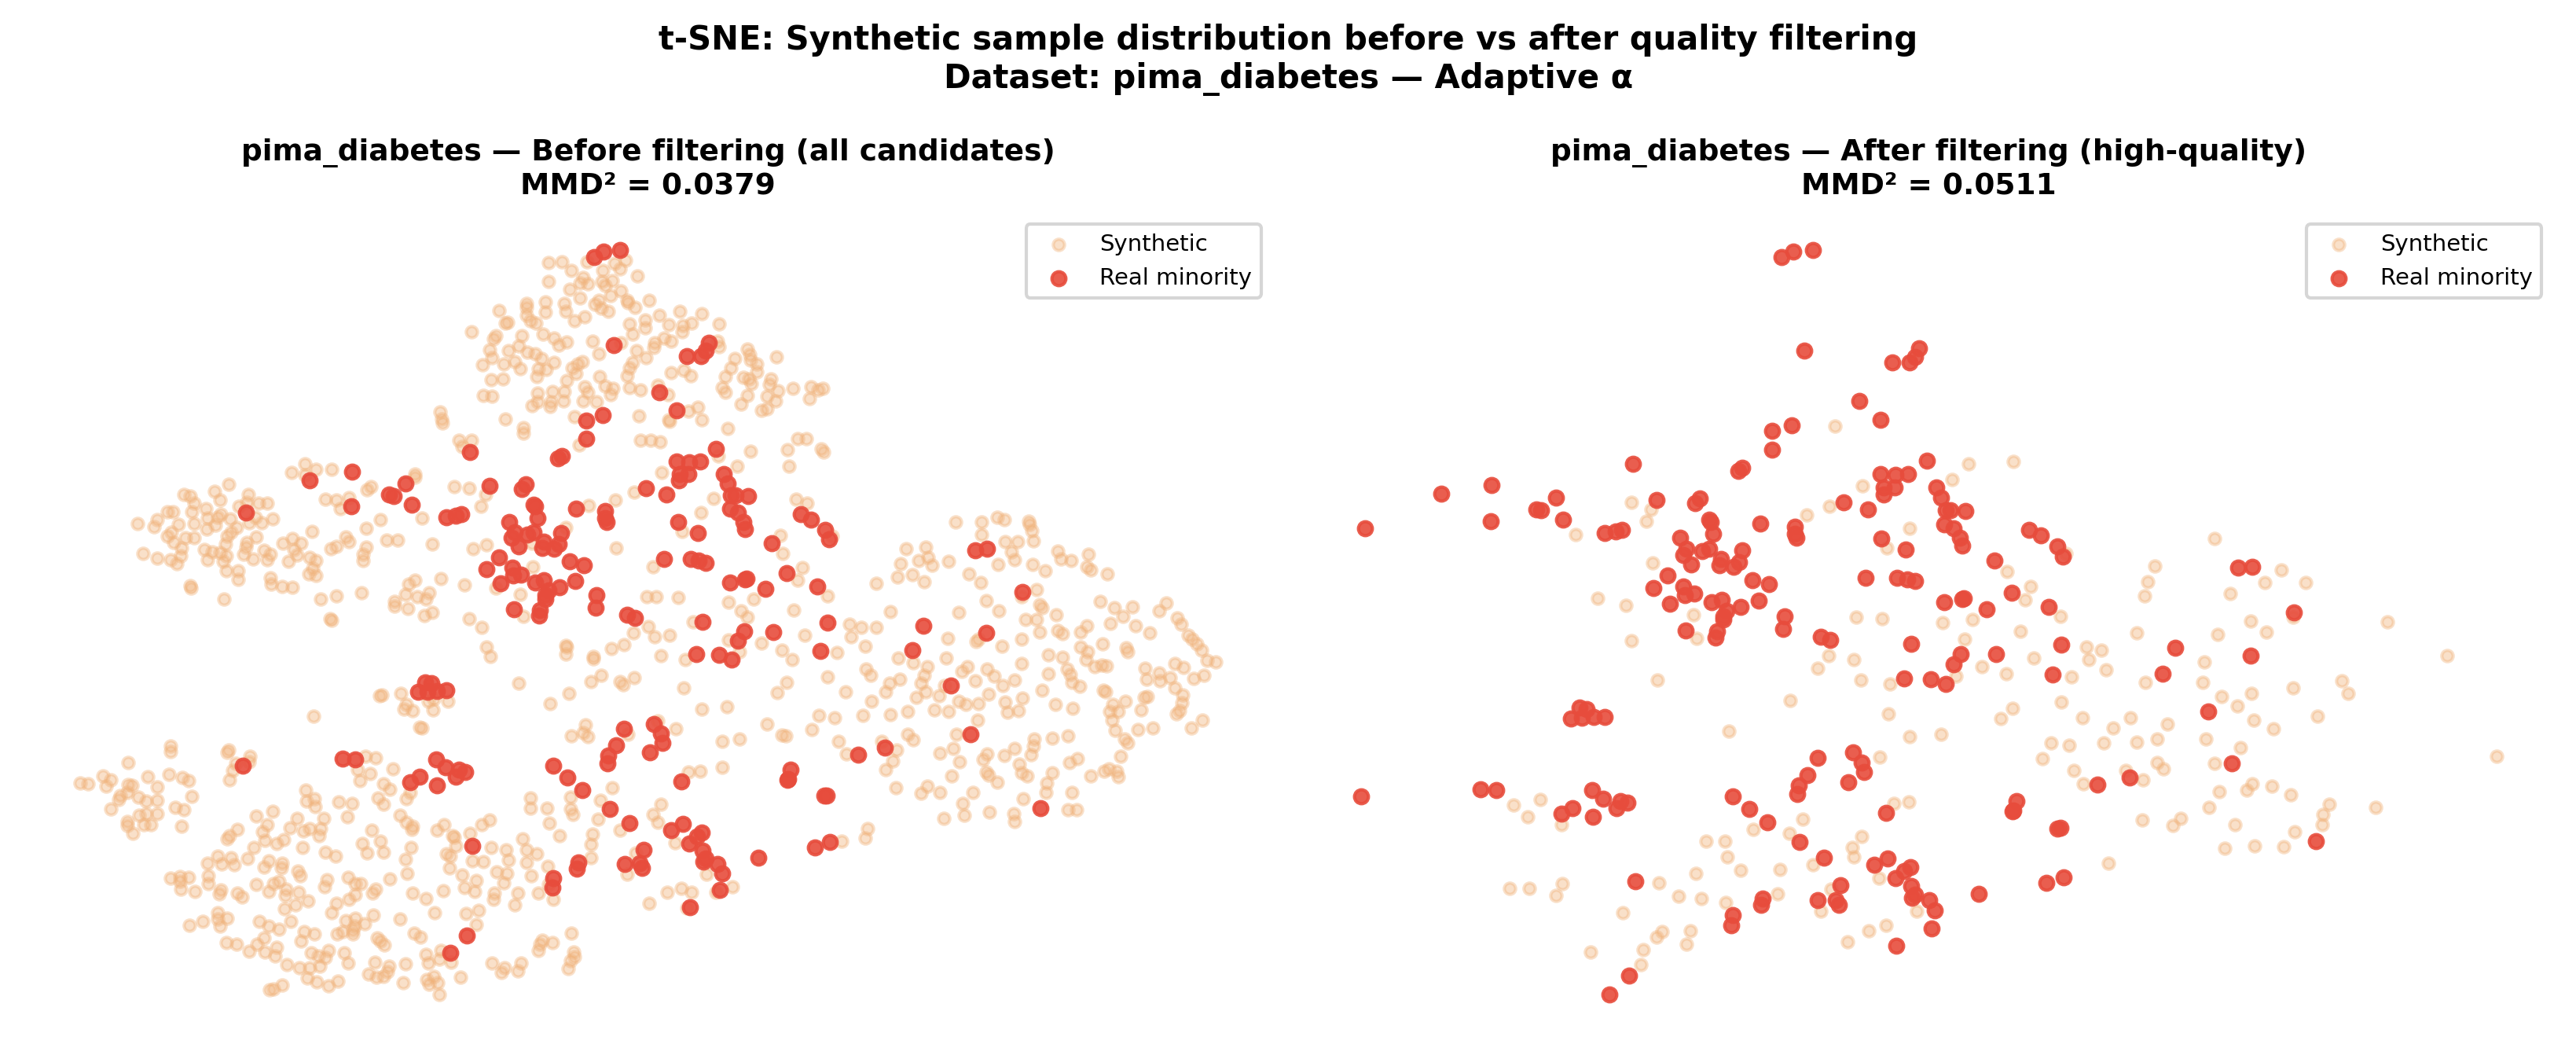

    Cluster 0: n=32  ✓
    Cluster 2: n=3  ✓
Figure saved → ./results\03_tsne_yeast_me2.png / .pdf


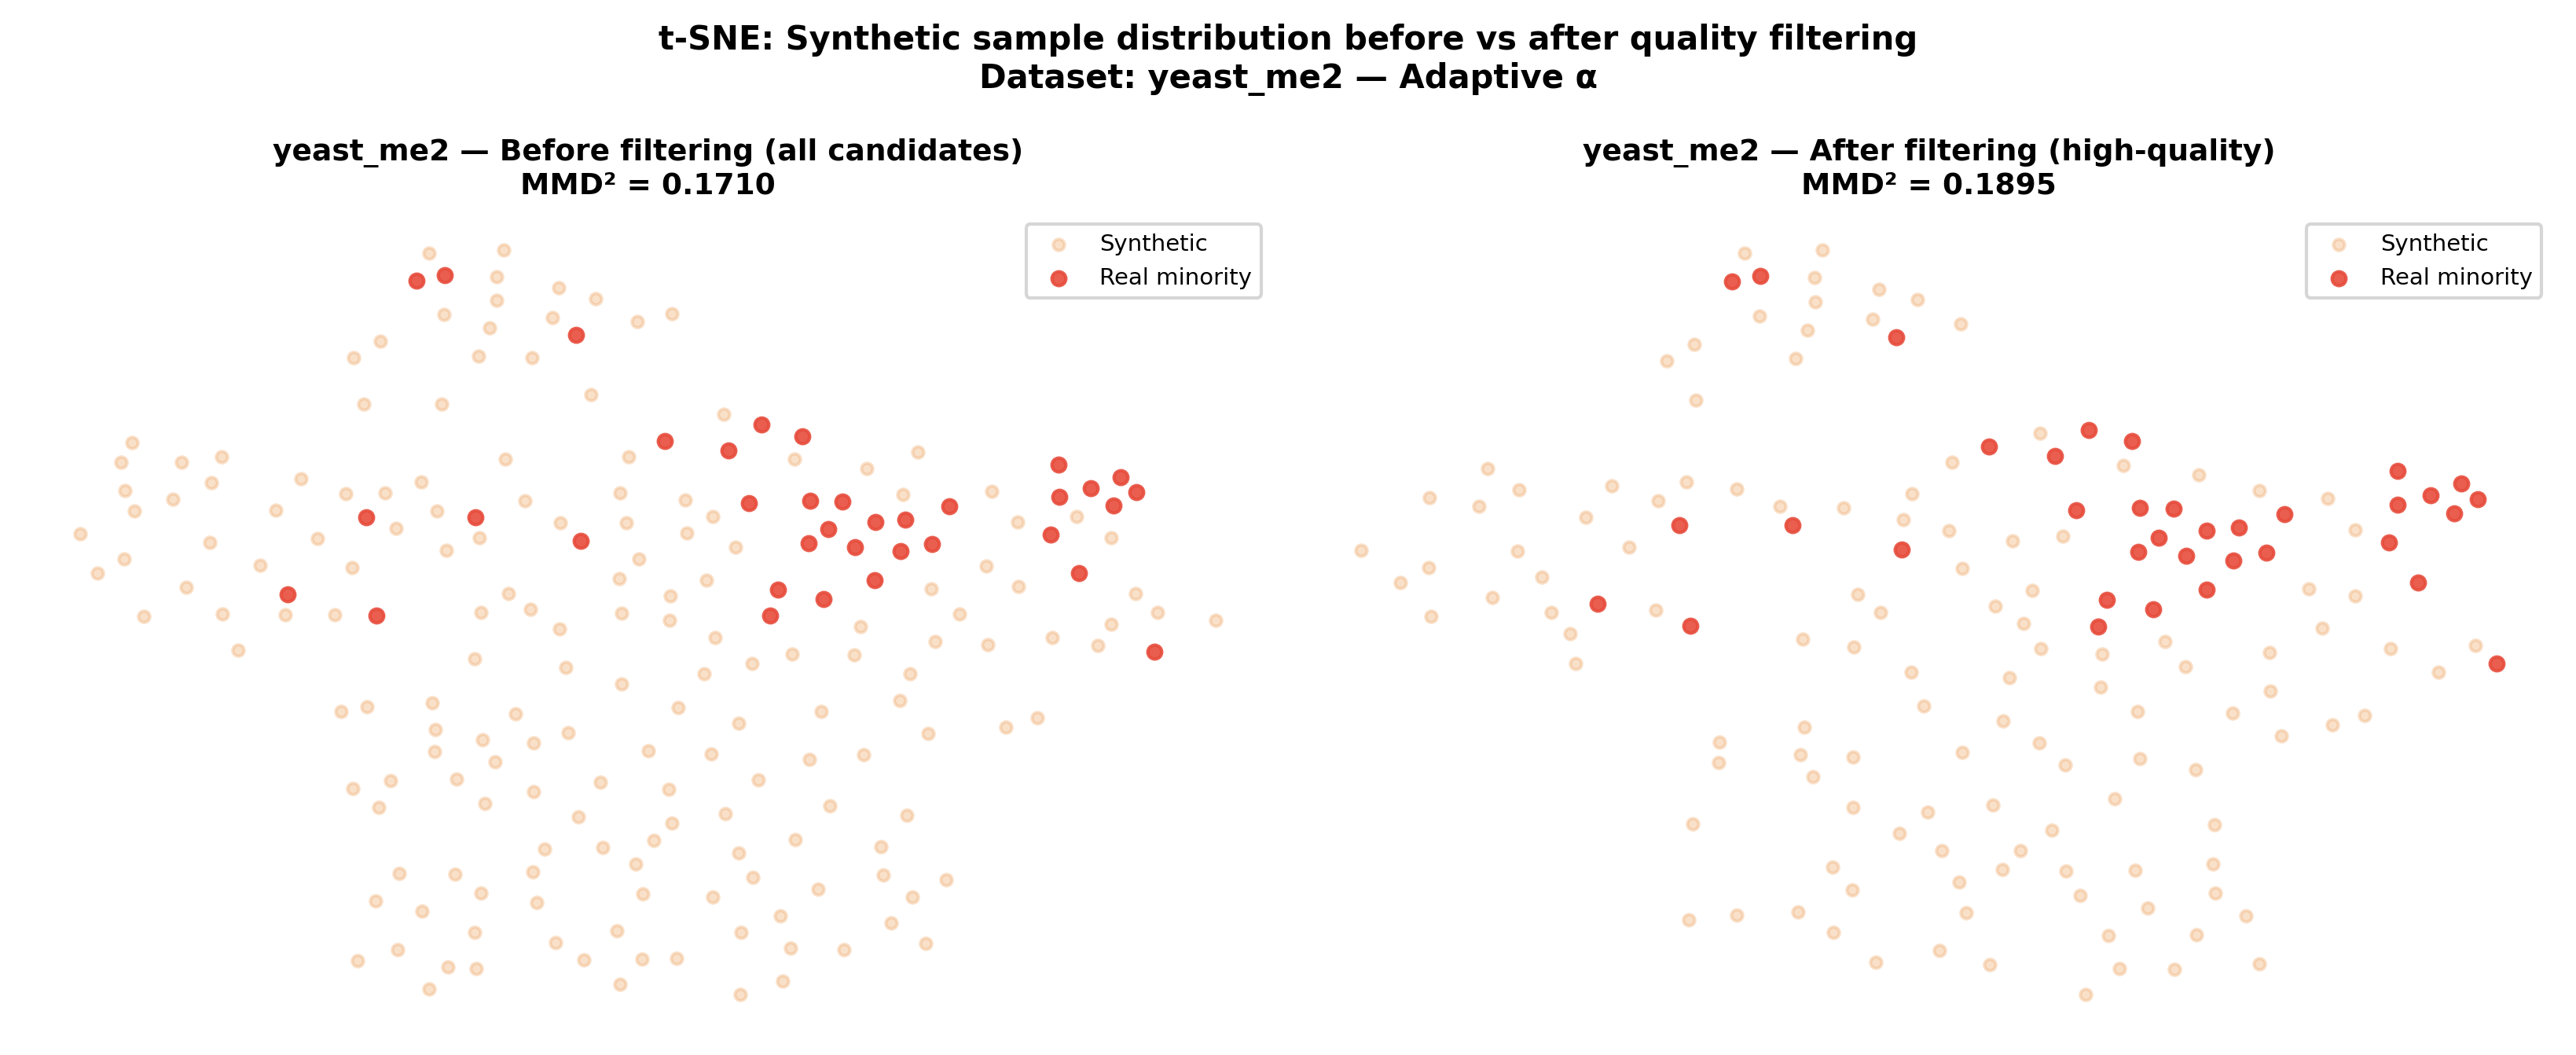

In [1]:
# 03. Q-G-CTGAN (Proposed Method)
# Q-G-CTGAN: Quality-Aware Cluster-Conditioned Oversampling
#             via Intra-Cluster Synthetic Sample Filtering
#
# Pipeline:
#   1. GMM clustering on minority class (BIC-optimal k*)
#   2. Per-cluster CTGAN training (once)
#   3. Candidate generation: N_c = round(n_min_c * CANDIDATE_MULTIPLIER) per cluster
#   4. Two-stage quality filtering:
#        Stage 1 — Q(x̃) = (1/3)*S_density + (1/3)*S_sep + (1/3)*S_lof
#        Stage 2 — MMD contribution-based final selection
#   5. Adaptive threshold α_c (GMM log-likelihood based)
#   6. Fixed α ablation: α ∈ {0.1, 0.2, 0.3}
#   7. MMD-based distribution proximity verification
#
# Reads  : ./datasets/*.csv
# Writes : ./results/03_*.csv / *.png / *.pdf


# ════════════════════════════════════════════════════════════
## 0. Setup
# ════════════════════════════════════════════════════════════

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore")

DATASET_DIR  = "./datasets"
RESULTS_DIR  = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATASET_NAMES = [
    "credit_default", "fraud_detection", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "mammography", "abalone_19", "wine_quality",
    "ecoli", "pageblocks", "protein_homo",
]

CLASSIFIERS = ["RF", "LGBM", "MLP"]

CANDIDATE_MULTIPLIER = 5.0
ALPHA_FIXED          = [0.1, 0.2, 0.3]
ALPHA_MIN            = 0.1
ALPHA_MAX            = 0.3
TARGET_RATIO         = 0.50

# Global figure quality settings (journal-ready)
mpl.rcParams.update({
    "figure.dpi"     : 300,
    "savefig.dpi"    : 300,
    "font.size"      : 9,
    "axes.titlesize" : 11,
    "axes.labelsize" : 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.family"    : "sans-serif",
    "pdf.fonttype"   : 42,
    "ps.fonttype"    : 42,
})

def save_fig(fig, path_no_ext):
    """Save figure as PNG (300 dpi) and PDF (vector) simultaneously."""
    fig.savefig(path_no_ext + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(path_no_ext + ".pdf",           bbox_inches="tight")
    print(f"Figure saved → {path_no_ext}.png / .pdf")

print(f"Datasets           : {len(DATASET_NAMES)}")
print(f"Classifiers        : {CLASSIFIERS}")
print(f"Candidate mult.    : {CANDIDATE_MULTIPLIER}x")
print(f"Fixed α values     : {ALPHA_FIXED}")
print(f"Adaptive α range   : [{ALPHA_MIN}, {ALPHA_MAX}]")
print(f"Target ratio       : {TARGET_RATIO}")


# ════════════════════════════════════════════════════════════
## 1. Classifiers & Evaluation
# ════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from lightgbm import LGBMClassifier


def get_classifier(name, random_state=RANDOM_STATE):
    if name == "RF":
        return RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=3,
            class_weight="balanced", random_state=random_state, n_jobs=-1,
        )
    elif name == "LGBM":
        return LGBMClassifier(
            n_estimators=100, learning_rate=0.05, num_leaves=31,
            class_weight="balanced", random_state=random_state,
            n_jobs=-1, verbose=-1,
        )
    elif name == "MLP":
        return MLPClassifier(
            hidden_layer_sizes=(128, 64), alpha=0.001,
            max_iter=300, random_state=random_state,
        )


def evaluate(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    return {
        "AUC"      : round(roc_auc_score(y_test, y_prob), 4),
        "F1"       : round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4),
    }

print("Classifiers & Evaluation ready.")


# ════════════════════════════════════════════════════════════
## 2. GMM Clustering
# ════════════════════════════════════════════════════════════

from sklearn.mixture import GaussianMixture


def fit_gmm(X_min, k, random_state=RANDOM_STATE):
    gmm = GaussianMixture(
        n_components=k, covariance_type="full",
        random_state=random_state, max_iter=200,
    )
    gmm.fit(X_min)
    return gmm


def select_optimal_k(X_min, k_range=range(2, 11), random_state=RANDOM_STATE):
    bic_scores = {}
    for k in k_range:
        if len(X_min) < k * 2:
            break
        try:
            gmm = fit_gmm(X_min, k, random_state)
            bic_scores[k] = gmm.bic(X_min)
        except Exception:
            continue
    if not bic_scores:
        return 2, {}, fit_gmm(X_min, 2, random_state)
    best_k   = min(bic_scores, key=bic_scores.get)
    best_gmm = fit_gmm(X_min, best_k, random_state)
    return best_k, bic_scores, best_gmm

print("GMM clustering ready.")


# ════════════════════════════════════════════════════════════
## 3. Quality Score Functions  (Stage 1 core)
# ════════════════════════════════════════════════════════════

from scipy.spatial.distance import cdist
from sklearn.neighbors import LocalOutlierFactor


def s_density(X_syn, mu_c, sigma_c):
    """S_density = exp(-D_M(x̃, μ_c, Σ_c)) — intra-cluster density score."""
    try:
        sigma_inv = np.linalg.pinv(sigma_c)
        diff      = X_syn - mu_c
        maha      = np.sqrt(np.einsum("ij,jk,ik->i", diff, sigma_inv, diff))
        return np.exp(-maha)
    except Exception:
        return np.ones(len(X_syn)) * 0.5


def s_sep(X_syn, mu_minority_all, mu_majority_clusters, eps=1e-8):
    """S_sep = d_maj / (d_maj + d_min + ε) — class separability score."""
    d_maj = cdist(X_syn, mu_majority_clusters).min(axis=1)
    d_min = cdist(X_syn, mu_minority_all).min(axis=1)
    return d_maj / (d_maj + d_min + eps)


def s_lof(X_syn, X_cluster_real, n_neighbors=5):
    """S_lof = 1 / LOF(x̃) — local outlier score (computed within cluster only)."""
    X_combined = np.vstack([X_cluster_real, X_syn])
    n_nb = min(n_neighbors, len(X_cluster_real) - 1)
    if n_nb < 1:
        return np.ones(len(X_syn)) * 0.5
    try:
        lof      = LocalOutlierFactor(n_neighbors=n_nb, novelty=False)
        lof.fit_predict(X_combined)
        lof_vals = -lof.negative_outlier_factor_[len(X_cluster_real):]
        return 1.0 / np.maximum(lof_vals, 1e-8)
    except Exception:
        return np.ones(len(X_syn)) * 0.5


def quality_score(X_syn, mu_c, sigma_c, mu_minority_all,
                  mu_majority_clusters, X_cluster_real,
                  w=(1/3, 1/3, 1/3)):
    """Q(x̃) = w1*S_density + w2*S_sep + w3*S_lof  (all normalised to [0,1])."""
    sd = s_density(X_syn, mu_c, sigma_c)
    ss = s_sep(X_syn, mu_minority_all, mu_majority_clusters)
    sl = s_lof(X_syn, X_cluster_real)

    def norm(v):
        lo, hi = v.min(), v.max()
        return (v - lo) / (hi - lo + 1e-8)

    return w[0]*norm(sd) + w[1]*norm(ss) + w[2]*norm(sl)

print("Quality score functions ready.")


# ════════════════════════════════════════════════════════════
## 4. Adaptive α  (GMM log-likelihood based)
# ════════════════════════════════════════════════════════════

def compute_adaptive_alpha(gmm, X_min, labels, best_k,
                           alpha_min=ALPHA_MIN, alpha_max=ALPHA_MAX):
    """
    α_c = alpha_max - (alpha_max - alpha_min) * ℓ̃_c
    High log-likelihood (stable cluster)  → small α_c → less filtering
    Low  log-likelihood (unstable cluster) → large α_c → more filtering
    """
    log_liks = []
    for c in range(best_k):
        X_c = X_min[labels == c]
        ll  = gmm.score_samples(X_c).mean() if len(X_c) >= 2 else -np.inf
        log_liks.append(ll)

    ll = np.array(log_liks, dtype=float)
    valid = ll[np.isfinite(ll)]
    if len(valid) == 0:
        return np.full(best_k, (alpha_min + alpha_max) / 2)
    ll = np.where(np.isfinite(ll), ll, valid.min())

    ll_min, ll_max = ll.min(), ll.max()
    ll_norm = (ll - ll_min) / (ll_max - ll_min + 1e-8)
    return np.clip(alpha_max - (alpha_max - alpha_min) * ll_norm,
                   alpha_min, alpha_max)

print("Adaptive α ready.")


# ════════════════════════════════════════════════════════════
## 5. MMD  (distribution proximity verification)
# ════════════════════════════════════════════════════════════

def rbf_kernel(X, Y, gamma=None):
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    XX = np.sum(X**2, axis=1, keepdims=True)
    YY = np.sum(Y**2, axis=1, keepdims=True)
    return np.exp(-gamma * (XX + YY.T - 2 * X @ Y.T))


def median_bandwidth(X, Y, sample_size=500):
    """Median heuristic: gamma = 1 / (2 * median(pairwise_dist²))."""
    rng = np.random.default_rng(RANDOM_STATE)
    Xs  = X[rng.choice(len(X), min(sample_size, len(X)), replace=False)]
    Ys  = Y[rng.choice(len(Y), min(sample_size, len(Y)), replace=False)]
    Z   = np.vstack([Xs, Ys])
    d   = cdist(Z, Z, metric="sqeuclidean")
    return 1.0 / (2.0 * np.median(d[d > 0]) + 1e-8)


def mmd_squared(X, Y, min_samples=10):
    """MMD²(P,Q) with median heuristic bandwidth. Returns NaN if too few samples."""
    if len(X) < min_samples or len(Y) < min_samples:
        return np.nan
    gamma = median_bandwidth(X, Y)
    return float(rbf_kernel(X, X, gamma).mean()
                 - 2 * rbf_kernel(X, Y, gamma).mean()
                 + rbf_kernel(Y, Y, gamma).mean())


def mmd_contribution(x_new, X_ref, X_pool, gamma):
    """
    Approximate MMD² change when adding x_new to synthetic set.
    Lower score → x_new reduces MMD → closer to real minority distribution.
    """
    k_xref = rbf_kernel(x_new.reshape(1, -1), X_ref, gamma).mean()
    k_xsyn = rbf_kernel(x_new.reshape(1, -1), X_pool, gamma).mean() \
              if len(X_pool) > 0 else 0.0
    return float(-2 * k_xref + k_xsyn)

print("MMD ready.")


# ════════════════════════════════════════════════════════════
## 6. CTGAN Training & Candidate Generation
# ════════════════════════════════════════════════════════════

from ctgan import CTGAN


def train_ctgan_per_cluster(X_min, labels, best_k, random_state=RANDOM_STATE):
    """Train one CTGAN model per GMM cluster."""
    ctgan_models = {}
    for c in range(best_k):
        X_c = X_min[labels == c]
        if len(X_c) < 2:
            ctgan_models[c] = None
            continue
        cols   = [f"f{i}" for i in range(X_c.shape[1])]
        X_c_df = pd.DataFrame(X_c, columns=cols)
        try:
            model = CTGAN(epochs=100, verbose=False)
            model.fit(X_c_df)
            ctgan_models[c] = model
            print(f"    Cluster {c}: n={len(X_c)}  ✓")
        except Exception as e:
            ctgan_models[c] = None
            print(f"    Cluster {c}: failed ({e})")
    return ctgan_models


def generate_candidates(X_min, labels, best_k, ctgan_models,
                        multiplier=CANDIDATE_MULTIPLIER):
    """Generate N_c = round(n_min_c * multiplier) candidate samples per cluster."""
    candidates = {}
    for c in range(best_k):
        X_c   = X_min[labels == c]
        n_gen = max(int(np.round(len(X_c) * multiplier)), 10)
        if ctgan_models.get(c) is None or len(X_c) < 2:
            candidates[c] = np.empty((0, X_min.shape[1]))
            continue
        try:
            candidates[c] = ctgan_models[c].sample(n_gen).values.astype(float)
        except Exception:
            candidates[c] = np.empty((0, X_min.shape[1]))
    return candidates

print("CTGAN functions ready.")


# ════════════════════════════════════════════════════════════
## 7. Two-Stage Quality Filtering  (core contribution)
# ════════════════════════════════════════════════════════════

def filter_by_quality(candidates, X_min, labels, X_maj, gmm, best_k,
                      alpha_vec, target_ratio=TARGET_RATIO):
    """
    Stage 1 — Remove bottom α_c fraction by Q(x̃) score (intra-cluster outlier removal)
    Stage 2 — Select top n_needed samples by MMD contribution score
               (prioritise samples closest to real minority distribution)
    """
    n_maj = len(X_maj)
    n_min = len(X_min)
    n_syn_needed = max(int(np.round(
        (target_ratio * (n_maj + n_min) - n_min) / (1 - target_ratio)
    )), 0)

    mu_minority_all      = gmm.means_
    mu_majority_clusters = np.array([X_maj.mean(axis=0)])

    # ── Stage 1: Q(x̃)-based per-cluster filtering ──────────────────
    filtered_per_cluster = {}
    quality_info         = {}

    for c in range(best_k):
        X_cand = candidates[c]
        X_c    = X_min[labels == c]

        if len(X_cand) == 0 or len(X_c) < 2:
            filtered_per_cluster[c] = np.empty((0, X_min.shape[1]))
            quality_info[c] = {"n_candidate": 0, "n_after_filter": 0,
                               "alpha": alpha_vec[c], "mean_Q_before": np.nan,
                               "mean_Q_after": np.nan}
            continue

        Q = quality_score(
            X_cand, gmm.means_[c], gmm.covariances_[c],
            mu_minority_all, mu_majority_clusters, X_c,
        )
        alpha_c   = alpha_vec[c]
        threshold = np.quantile(Q, alpha_c)
        mask      = Q >= threshold
        X_filt    = X_cand[mask]

        quality_info[c] = {
            "n_candidate"   : len(X_cand),
            "n_after_filter": int(mask.sum()),
            "alpha"         : round(float(alpha_c), 3),
            "mean_Q_before" : round(float(Q.mean()), 4),
            "mean_Q_after"  : round(float(Q[mask].mean()), 4) if mask.sum() > 0 else np.nan,
        }
        filtered_per_cluster[c] = X_filt

    # ── Stage 2: MMD contribution-based final selection ─────────────
    all_filtered = [v for v in filtered_per_cluster.values() if len(v) > 0]
    if not all_filtered:
        return np.empty((0, X_min.shape[1])), quality_info

    X_pool = np.vstack(all_filtered)
    if len(X_pool) <= n_syn_needed:
        return X_pool, quality_info

    gamma = median_bandwidth(X_min, X_pool)
    mmd_scores = np.array([
        mmd_contribution(X_pool[i], X_min, X_pool, gamma)
        for i in range(len(X_pool))
    ])
    top_idx = np.argsort(mmd_scores)[:n_syn_needed]
    return X_pool[top_idx], quality_info

print("Two-stage filtering ready.")


# ════════════════════════════════════════════════════════════
## 8. Q-G-CTGAN Core Pipeline
# ════════════════════════════════════════════════════════════

def apply_qgctgan(X_train, y_train, alpha_mode="adaptive",
                  alpha_fixed=0.2, random_state=RANDOM_STATE):
    """
    Full Q-G-CTGAN pipeline.
    alpha_mode : "adaptive" | "fixed"
    alpha_fixed : used only when alpha_mode == "fixed"
    """
    X_min = X_train[y_train == 1].astype(float)
    X_maj = X_train[y_train == 0].astype(float)

    # Step 1: GMM clustering
    best_k, bic_scores, gmm = select_optimal_k(X_min, random_state=random_state)
    labels        = gmm.predict(X_min)
    cluster_sizes = np.bincount(labels)
    print(f"  GMM: best_k={best_k}  cluster_sizes={cluster_sizes.tolist()}")

    # Step 2: Per-cluster CTGAN training
    print(f"  Training {best_k} CTGAN models...")
    ctgan_models = train_ctgan_per_cluster(X_min, labels, best_k, random_state)

    # Step 3: Candidate generation
    print(f"  Generating candidates (×{CANDIDATE_MULTIPLIER})...")
    candidates    = generate_candidates(X_min, labels, best_k, ctgan_models)
    n_cand_total  = sum(len(v) for v in candidates.values())
    print(f"  Total candidates generated: {n_cand_total:,}")

    # Step 4: Determine α vector
    if alpha_mode == "adaptive":
        alpha_vec = compute_adaptive_alpha(gmm, X_min, labels, best_k)
        print(f"  Adaptive α: {np.round(alpha_vec, 3)}")
    else:
        alpha_vec = np.full(best_k, alpha_fixed)
        print(f"  Fixed α={alpha_fixed} for all clusters")

    # Step 5: Two-stage quality filtering
    print(f"  Filtering by quality score Q(x̃)...")
    t_filter = time.time()
    X_syn, quality_info = filter_by_quality(
        candidates, X_min, labels, X_maj, gmm, best_k, alpha_vec
    )
    filter_time = round(time.time() - t_filter, 2)
    print(f"  Filtered: {n_cand_total:,} → {len(X_syn):,} samples [{filter_time:.1f}s]")

    # Step 6: MMD verification
    all_cand   = np.vstack([v for v in candidates.values() if len(v) > 0])
    mmd_before = mmd_squared(X_min, all_cand) if len(all_cand) > 0 else np.nan
    mmd_after  = mmd_squared(X_min, X_syn)    if len(X_syn)  > 0 else np.nan
    direction  = "↓ improved" if (not np.isnan(mmd_after) and
                                   not np.isnan(mmd_before) and
                                   mmd_after < mmd_before) else "↑ degraded"
    print(f"  MMD² before={mmd_before:.6f}  after={mmd_after:.6f}  ({direction})")

    # Step 7: Dataset reconstruction
    if len(X_syn) > 0:
        X_out = np.vstack([X_maj, X_min, X_syn])
        y_out = np.concatenate([
            np.zeros(len(X_maj)), np.ones(len(X_min)), np.ones(len(X_syn))
        ]).astype(int)
    else:
        X_out = np.vstack([X_maj, X_min])
        y_out = np.concatenate([np.zeros(len(X_maj)), np.ones(len(X_min))]).astype(int)

    minority_ratio = round((y_out == 1).sum() / len(y_out), 4)

    info = {
        "best_k"        : best_k,
        "cluster_sizes" : cluster_sizes.tolist(),
        "alpha_mode"    : alpha_mode,
        "alpha_vec"     : np.round(alpha_vec, 3).tolist(),
        "n_candidates"  : n_cand_total,
        "n_synthetic"   : len(X_syn),
        "minority_ratio": minority_ratio,
        "mmd_before"    : round(mmd_before, 6) if not np.isnan(mmd_before) else None,
        "mmd_after"     : round(mmd_after,  6) if not np.isnan(mmd_after)  else None,
        "filter_time"   : filter_time,
        "quality_info"  : quality_info,
    }
    return X_out, y_out, info

print("Q-G-CTGAN pipeline ready.")


# ════════════════════════════════════════════════════════════
## 9. Main Experiment Loop
# ════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ALPHA_MODES = (
    [("fixed", a) for a in ALPHA_FIXED]
    + [("adaptive", None)]
)

results  = []
mmd_logs = []
TOTAL    = len(DATASET_NAMES) * len(ALPHA_MODES) * len(CLASSIFIERS)
done     = 0

for ds_name in DATASET_NAMES:
    path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
    if not os.path.exists(path):
        print(f"[SKIP] {ds_name}")
        done += len(ALPHA_MODES) * len(CLASSIFIERS)
        continue

    df = pd.read_csv(path)
    X  = df.drop(columns=["target"]).values.astype(float)
    y  = df["target"].values.astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"\n{'='*65}")
    print(f"Dataset : {ds_name}  |  n_train={len(X_train):,}  |  "
          f"minority={y_train.mean():.2%}")
    print(f"{'='*65}")

    for (alpha_mode, alpha_fixed) in ALPHA_MODES:
        mode_label = f"Q-G-CTGAN_a{alpha_fixed}" if alpha_mode == "fixed" \
                     else "Q-G-CTGAN_adaptive"
        print(f"\n  ── {mode_label} ──")

        t0 = time.time()
        try:
            af = alpha_fixed if alpha_mode == "fixed" else 0.2
            X_res, y_res, info = apply_qgctgan(
                X_train.copy(), y_train.copy(),
                alpha_mode=alpha_mode, alpha_fixed=af,
            )
            total_time = round(time.time() - t0, 2)
            print(f"  Result: n={len(y_res):,}  "
                  f"minority={info['minority_ratio']:.2%}  [{total_time:.1f}s]")

            mmd_logs.append({
                "dataset"   : ds_name,
                "alpha_mode": mode_label,
                "mmd_before": info["mmd_before"],
                "mmd_after" : info["mmd_after"],
                "improved"  : (info["mmd_after"] or 1) < (info["mmd_before"] or 0),
            })

        except Exception as e:
            print(f"  Q-G-CTGAN failed [{mode_label}]: {e}")
            done += len(CLASSIFIERS)
            continue

        for clf_name in CLASSIFIERS:
            done += 1
            progress = f"[{done:>4}/{TOTAL}]"
            clf = get_classifier(clf_name)
            t1  = time.time()
            try:
                clf.fit(X_res, y_res)
                train_time = round(time.time() - t1, 2)
                metrics    = evaluate(clf, X_test, y_test)
            except Exception as e:
                print(f"  {progress} {clf_name} — Failed: {e}")
                continue

            results.append({
                "dataset"        : ds_name,
                "oversampling"   : mode_label,
                "classifier"     : clf_name,
                "alpha_mode"     : alpha_mode,
                "alpha_value"    : alpha_fixed if alpha_mode == "fixed" else "adaptive",
                "best_k"         : info["best_k"],
                "n_candidates"   : info["n_candidates"],
                "n_synthetic"    : info["n_synthetic"],
                "minority_ratio" : info["minority_ratio"],
                "mmd_before"     : info["mmd_before"],
                "mmd_after"      : info["mmd_after"],
                "filter_time"    : info["filter_time"],
                "train_time"     : train_time,
                **metrics,
            })
            print(f"  {progress} {ds_name} | {mode_label} | {clf_name:<5} | "
                  f"AUC={metrics['AUC']:.4f}  F1={metrics['F1']:.4f}  "
                  f"[{train_time:.1f}s]")

print("\nExperiment complete.")


# ════════════════════════════════════════════════════════════
## 10. Save Results
# ════════════════════════════════════════════════════════════

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(RESULTS_DIR, "03_qgctgan_results.csv"), index=False)
print(f"Results saved → {os.path.join(RESULTS_DIR, '03_qgctgan_results.csv')}")

mmd_df = pd.DataFrame(mmd_logs)
mmd_df.to_csv(os.path.join(RESULTS_DIR, "03_qgctgan_mmd.csv"), index=False)
print(f"MMD log saved → {os.path.join(RESULTS_DIR, '03_qgctgan_mmd.csv')}")

print("\nMean AUC by classifier & alpha mode:")
print(results_df.groupby(["oversampling", "classifier"])["AUC"]
      .mean().round(4).unstack().to_string())


# ════════════════════════════════════════════════════════════
## 11. MMD Analysis — Before vs After Filtering
# ════════════════════════════════════════════════════════════

mmd_df["mmd_reduction"] = mmd_df["mmd_before"] - mmd_df["mmd_after"]
mmd_df["improved"]      = mmd_df["mmd_reduction"] > 0

# Horizontal bar chart — datasets on y-axis to avoid x-axis crowding
alpha_modes = mmd_df["alpha_mode"].unique().tolist()
n_modes     = len(alpha_modes)

fig, axes = plt.subplots(1, n_modes, figsize=(5 * n_modes, 5.5), sharey=True)
if n_modes == 1:
    axes = [axes]

for ax, mode in zip(axes, alpha_modes):
    sub = mmd_df[mmd_df["alpha_mode"] == mode].reset_index(drop=True)
    y   = np.arange(len(sub))
    h   = 0.35

    ax.barh(y + h/2, sub["mmd_before"], height=h,
            color="#AED6F1", label="MMD² before", zorder=3)
    ax.barh(y - h/2, sub["mmd_after"],  height=h,
            color="#E74C3C", alpha=0.85, label="MMD² after", zorder=3)

    for i, row in sub.iterrows():
        sym   = "↓" if row["improved"] else "↑"
        color = "#27AE60" if row["improved"] else "#C0392B"
        xmax  = max(row["mmd_before"], row["mmd_after"])
        ax.text(xmax + 0.003, i, sym, ha="left", va="center",
                fontsize=11, color=color, fontweight="bold")

    ax.set_yticks(y)
    ax.set_yticklabels(sub["dataset"], fontsize=9)
    ax.set_xlabel("MMD²", fontsize=10)
    ax.set_title(f"α mode: {mode}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="x", alpha=0.3, zorder=0)
    xmax_all = sub[["mmd_before", "mmd_after"]].max().max()
    ax.set_xlim(0, xmax_all * 1.25)

improved_pct = mmd_df["improved"].mean() * 100
fig.suptitle(
    f"MMD² Before vs After Quality Filtering\n"
    f"(Filtering improved distributional proximity in {improved_pct:.1f}% of cases)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
save_fig(fig, os.path.join(RESULTS_DIR, "03_mmd_analysis"))
plt.show()

print("\nMMD Summary (mean per α mode):")
print(mmd_df.groupby("alpha_mode")[["mmd_before", "mmd_after", "mmd_reduction"]]
      .mean().round(4).to_string())


# ════════════════════════════════════════════════════════════
## 12. Ablation: Fixed α vs Adaptive α
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, clf_name in zip(axes, CLASSIFIERS):
    sub   = results_df[results_df["classifier"] == clf_name]
    pivot = (sub.groupby(["dataset", "oversampling"])["AUC"]
               .mean().unstack())
    alpha_cols = [c for c in pivot.columns if "Q-G-CTGAN" in c]
    pivot[alpha_cols].plot(kind="bar", ax=ax, width=0.75)
    ax.set_title(f"AUC by α mode — {clf_name}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Dataset", fontsize=9)
    ax.set_ylabel("AUC", fontsize=9)
    ax.set_ylim(0.5, 1.0)
    ax.legend(fontsize=7, loc="lower right")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)

plt.suptitle("Q-G-CTGAN Ablation: Fixed α vs Adaptive α",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, os.path.join(RESULTS_DIR, "03_ablation_alpha"))
plt.show()


# ════════════════════════════════════════════════════════════
## 13. Quality Indicator Ablation (S_density / S_sep / S_lof)
# ════════════════════════════════════════════════════════════

def apply_qgctgan_ablation(X_train, y_train, weight_mode="full",
                            random_state=RANDOM_STATE):
    """
    weight_mode : "full"    → w = (1/3, 1/3, 1/3)
                  "density" → w = (1, 0, 0)
                  "sep"     → w = (0, 1, 0)
                  "lof"     → w = (0, 0, 1)
    """
    w_map = {
        "full"   : (1/3, 1/3, 1/3),
        "density": (1,   0,   0),
        "sep"    : (0,   1,   0),
        "lof"    : (0,   0,   1),
    }
    w     = w_map[weight_mode]
    X_min = X_train[y_train == 1].astype(float)
    X_maj = X_train[y_train == 0].astype(float)

    best_k, _, gmm = select_optimal_k(X_min, random_state=random_state)
    labels         = gmm.predict(X_min)
    ctgan_models   = train_ctgan_per_cluster(X_min, labels, best_k, random_state)
    candidates     = generate_candidates(X_min, labels, best_k, ctgan_models)
    alpha_vec      = compute_adaptive_alpha(gmm, X_min, labels, best_k)

    n_maj = len(X_maj); n_min = len(X_min)
    n_syn_needed = max(int(np.round(
        (TARGET_RATIO * (n_maj + n_min) - n_min) / (1 - TARGET_RATIO)
    )), 0)

    mu_minority_all      = gmm.means_
    mu_majority_clusters = np.array([X_maj.mean(axis=0)])

    all_syn = []
    for c in range(best_k):
        X_cand = candidates[c]; X_c = X_min[labels == c]
        if len(X_cand) == 0 or len(X_c) < 2:
            continue
        Q    = quality_score(X_cand, gmm.means_[c], gmm.covariances_[c],
                             mu_minority_all, mu_majority_clusters, X_c, w=w)
        mask = Q >= np.quantile(Q, alpha_vec[c])
        all_syn.append(X_cand[mask])

    if not all_syn:
        X_out = np.vstack([X_maj, X_min])
        return X_out, np.concatenate([np.zeros(n_maj), np.ones(n_min)]).astype(int)

    X_pool = np.vstack(all_syn)
    if len(X_pool) > n_syn_needed:
        gamma      = median_bandwidth(X_min, X_pool)
        mmd_scores = np.array([
            mmd_contribution(X_pool[i], X_min, X_pool, gamma)
            for i in range(len(X_pool))
        ])
        X_pool = X_pool[np.argsort(mmd_scores)[:n_syn_needed]]

    X_out = np.vstack([X_maj, X_min, X_pool])
    y_out = np.concatenate([
        np.zeros(n_maj), np.ones(n_min), np.ones(len(X_pool))
    ]).astype(int)
    return X_out, y_out


ABLATION_MODES   = ["full", "density", "sep", "lof"]
ablation_results = []

print("\nRunning quality indicator ablation (RF only)...")
for ds_name in DATASET_NAMES:
    path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)
    X  = df.drop(columns=["target"]).values.astype(float)
    y  = df["target"].values.astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    for wmode in ABLATION_MODES:
        try:
            X_res, y_res = apply_qgctgan_ablation(
                X_train.copy(), y_train.copy(), weight_mode=wmode
            )
            clf = get_classifier("RF")
            clf.fit(X_res, y_res)
            metrics = evaluate(clf, X_test, y_test)
            ablation_results.append({
                "dataset": ds_name, "weight_mode": wmode, **metrics
            })
            print(f"  {ds_name} | {wmode:<8} | AUC={metrics['AUC']:.4f}")
        except Exception as e:
            print(f"  {ds_name} | {wmode} | Error: {e}")

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv(os.path.join(RESULTS_DIR, "03_ablation_quality.csv"), index=False)
print(f"\nAblation saved → {os.path.join(RESULTS_DIR, '03_ablation_quality.csv')}")
print(ablation_df.groupby("weight_mode")["AUC"].mean().round(4).to_string())


# ════════════════════════════════════════════════════════════
## 14. t-SNE Visualization — Before vs After Filtering
# ════════════════════════════════════════════════════════════

from sklearn.manifold import TSNE

def plot_tsne_filter(ds_name, random_state=RANDOM_STATE):
    path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
    if not os.path.exists(path):
        print(f"Dataset not found: {ds_name}")
        return

    df     = pd.read_csv(path)
    X      = df.drop(columns=["target"]).values.astype(float)
    y      = df["target"].values.astype(int)
    X_tr, _, y_tr, _ = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=random_state
    )
    X_tr = StandardScaler().fit_transform(X_tr)

    X_min = X_tr[y_tr == 1].astype(float)
    X_maj = X_tr[y_tr == 0].astype(float)

    best_k, _, gmm = select_optimal_k(X_min, random_state=random_state)
    labels         = gmm.predict(X_min)
    ctgan_models   = train_ctgan_per_cluster(X_min, labels, best_k, random_state)
    candidates     = generate_candidates(X_min, labels, best_k, ctgan_models)
    alpha_vec      = compute_adaptive_alpha(gmm, X_min, labels, best_k)
    X_syn_filt, _  = filter_by_quality(
        candidates, X_min, labels, X_maj, gmm, best_k, alpha_vec
    )
    X_cand_all = np.vstack([v for v in candidates.values() if len(v) > 0])

    if len(X_cand_all) == 0 or len(X_syn_filt) == 0:
        print(f"  Skipping t-SNE for {ds_name}: no synthetic samples.")
        return

    N_real = len(X_min)
    N_cand = len(X_cand_all)
    X_all  = np.vstack([X_min, X_cand_all, X_syn_filt])
    Z      = TSNE(n_components=2, random_state=random_state,
                  perplexity=min(30, len(X_all) - 1)).fit_transform(X_all)

    Z_real = Z[:N_real]
    Z_cand = Z[N_real:N_real + N_cand]
    Z_filt = Z[N_real + N_cand:]

    mmd_b  = mmd_squared(X_min, X_cand_all)
    mmd_a  = mmd_squared(X_min, X_syn_filt)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, (Z_syn, title, mmd_val) in zip(axes, [
        (Z_cand, "Before filtering (all candidates)", mmd_b),
        (Z_filt, "After filtering (high-quality)",    mmd_a),
    ]):
        ax.scatter(Z_syn[:, 0], Z_syn[:, 1],
                   c="#F0B27A", alpha=0.4, s=12, label="Synthetic")
        ax.scatter(Z_real[:, 0], Z_real[:, 1],
                   c="#E74C3C", alpha=0.9, s=18, label="Real minority")
        mmd_str = f"{mmd_val:.4f}" if not np.isnan(mmd_val) else "N/A"
        ax.set_title(f"{ds_name} — {title}\nMMD² = {mmd_str}",
                     fontsize=9, fontweight="bold")
        ax.legend(fontsize=7, loc="upper right")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)

    plt.suptitle(
        f"t-SNE: Synthetic sample distribution before vs after quality filtering\n"
        f"Dataset: {ds_name} — Adaptive α",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    save_fig(fig, os.path.join(RESULTS_DIR, f"03_tsne_{ds_name}"))
    plt.show()


for ds in ["pima_diabetes", "yeast_me2"]:
    plot_tsne_filter(ds)